In [2]:
import pandas as pd
import matplotlib.pyplot as plt     
import numpy as np
import seaborn as sns   

df_origin = pd.read_csv('UsedCarsSA_Unclean_EN.csv')
df = df_origin.copy()

In [3]:
df.sample(5)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
4490,Ford,Taurus,2016,Other,Grey,Semi Full,3.5,Gas,Automatic,Used,123000,Dammam,65000,False
5873,GMC,Yukon,2017,Saudi,Black,Standard,NaN,Gas,Automatic,Used,139000,Riyadh,Negotiable,True
6736,Ford,Expedition,2015,Saudi,Another Color,Semi Full,NaN,Gas,Automatic,Used,1330000,Riyadh,Negotiable,True
6407,Ford,Taurus,2010,Other,Another Color,Semi Full,NaN,Gas,Automatic,Used,380,Al-Baha,28000,False
1995,Nissan,Datsun,1984,Saudi,White,Standard,NaN,Gas,Manual,Used,248000,Riyadh,7000,False


In [4]:
df.shape

(8248, 14)

In [5]:
df.describe()

,Year,Engine_Size,Mileage
count,8248.000000,5982.000000,8.248000e+03
mean,2014.014064,3.175794,1.494128e+05
std,5.935349,1.567480,3.455258e+05
min,1936.000000,1.000000,1.000000e+02
25%,2012.000000,2.000000,3.700000e+04
50%,2016.000000,2.700000,1.016575e+05
75%,2018.000000,4.000000,1.955520e+05
max,2022.000000,9.000000,2.000000e+07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8248 non-null   object 
 1   Type         8248 non-null   object 
 2   Year         8248 non-null   int64  
 3   Origin       8153 non-null   object 
 4   Color        8248 non-null   object 
 5   Options      8139 non-null   object 
 6   Engine_Size  5982 non-null   float64
 7   Fuel_Type    8248 non-null   object 
 8   Gear_Type    8174 non-null   object 
 9   Condition    8248 non-null   object 
 10  Mileage      8248 non-null   int64  
 11  Region       8248 non-null   object 
 12  Price        8248 non-null   object 
 13  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(10)
memory usage: 845.9+ KB


Cleaning

In [7]:
# Origin, Options, Engine_Size and Gear_Type columns have some missing values, we need to handle them 
# Price column has some non-numeric values, we need to clean it

In [8]:
df.duplicated().sum()   

np.int64(69)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum() 

Make              0
Type              0
Year              0
Origin           95
Color             0
Options         109
Engine_Size    2254
Fuel_Type         0
Gear_Type        74
Condition         0
Mileage           0
Region            0
Price             0
Negotiable        0
dtype: int64

In [11]:
print(9500/8248)
# so the missing values in Origin column is around 1.15%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Origin'])

1.1517943743937924


In [12]:
print(10900/8248)
# so the missing values in Options column is around 1.32%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Options'])

1.3215324927255092


In [13]:
print(7400/8248)
# so the missing values in Gear_Type column is around 0.74%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Gear_Type'])

0.8971871968962173


In [14]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Engine_Size']
      .transform('mean')
)

In [15]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Make', 'Type', 'Year'])['Engine_Size']
      .transform('mean')
)

In [16]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'].info()

<class 'pandas.core.series.Series'>
Index: 8051 entries, 0 to 8247
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
5546 non-null   float64
dtypes: float64(1)
memory usage: 125.8 KB


In [17]:
df['Price'] = df['Price'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Price']
     .transform('mean'))

In [18]:
df.isna().sum()

Make             0
Type             0
Year             0
Origin           0
Color            0
Options          0
Engine_Size    430
Fuel_Type        0
Gear_Type        0
Condition        0
Mileage          0
Region           0
Price          503
Negotiable       0
dtype: int64

In [19]:
df['Engine_Size'] = df['Engine_Size'].fillna(df['Engine_Size'].mean())

In [20]:
df['Price'] = df['Price'].fillna(df['Price'].mean())

In [21]:
df.isna().sum() 

Make           0
Type           0
Year           0
Origin         0
Color          0
Options        0
Engine_Size    0
Fuel_Type      0
Gear_Type      0
Condition      0
Mileage        0
Region         0
Price          0
Negotiable     0
dtype: int64

In [22]:
df['Car_Age'] = 2024 - df['Year']
df['Car_Age']

0        6
1        8
2        5
3        5
4        5
        ..
8243     9
8244    14
8245    11
8246    13
8247    11
Name: Car_Age, Length: 8051, dtype: int64

<Axes: title={'center': 'Price Distribution'}>

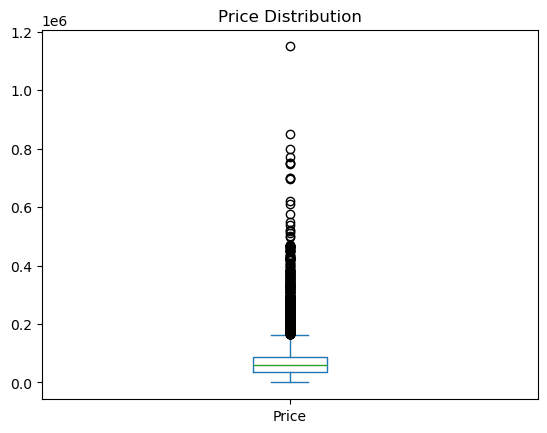

In [23]:
df['Price'].plot(kind='box', title='Price Distribution')

In [24]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f'Number of outliers in Price: {len(outliers)}')

Number of outliers in Price: 633


In [25]:
df[df['Price'] > upper_bound].sample(10)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable,Car_Age
83,Mercedes,S,2018,Saudi,Grey,Full,3.785714,Gas,Automatic,Used,73000,Riyadh,345000.0,False,6
5511,Lincoln,Continental GT,2020,Saudi,Grey,Semi Full,3.700000,Gas,Automatic,Used,3500,Dammam,250000.0,False,4
3023,Toyota,Land Cruiser,2019,Gulf Arabic,White,Full,4.000000,Gas,Automatic,Used,30000,Riyadh,194500.0,False,5
927,GMC,Sierra,2021,Saudi,Black,Full,7.433333,Gas,Automatic,Used,2000,Khobar,190000.0,False,3
4188,Lexus,LX,2015,Saudi,Golden,Full,5.700000,Gas,Automatic,Used,157000,Al-Medina,196375.0,True,9
1763,Mercedes,C,2019,Gulf Arabic,Black,Full,2.000000,Gas,Automatic,Used,15000,Makkah,175000.0,False,5
936,BMW,X,2020,Other,White,Standard,2.750000,Gas,Automatic,Used,20000,Riyadh,257000.0,False,4
3854,Nissan,Patrol,2020,Saudi,Silver,Full,4.000000,Gas,Automatic,Used,56000,Dammam,225000.0,False,4
7945,Lexus,ES,2021,Saudi,Another Color,Standard,2.500000,Gas,Automatic,Used,6000,Dammam,175000.0,False,3
7771,Audi,A8,2016,Gulf Arabic,White,Semi Full,4.650000,Gas,Automatic,Used,125000,Riyadh,165000.0,True,8


c:\Users\watan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: title={'center': 'Log-Transformed Price Distribution'}>

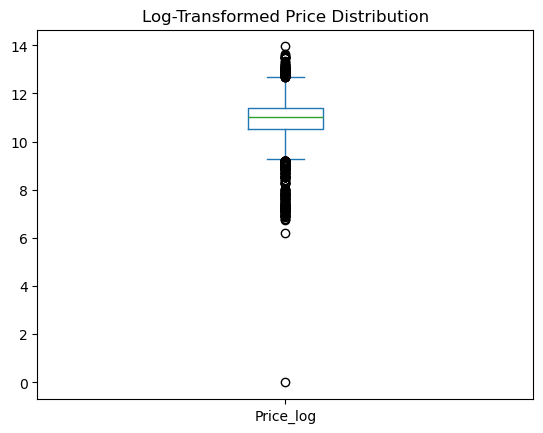

In [26]:
df['Price_log'] = np.log(df['Price'])
df['Price_log'].plot(kind='box', title='Log-Transformed Price Distribution')

In [27]:
df['Category'] = pd.cut(df['Price'],
                       bins=[0,50000,100000,150000,df['Price'].max()],
                        labels=['Budget', 'Mid', 'Premium', 'Luxury'])


In [28]:
df['Category'].value_counts()

Category
Budget     3265
Mid        3113
Premium     921
Luxury      751
Name: count, dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         8051 non-null   object  
 1   Type         8051 non-null   object  
 2   Year         8051 non-null   int64   
 3   Origin       8051 non-null   object  
 4   Color        8051 non-null   object  
 5   Options      8051 non-null   object  
 6   Engine_Size  8051 non-null   float64 
 7   Fuel_Type    8051 non-null   object  
 8   Gear_Type    8051 non-null   object  
 9   Condition    8051 non-null   object  
 10  Mileage      8051 non-null   int64   
 11  Region       8051 non-null   object  
 12  Price        8051 non-null   float64 
 13  Negotiable   8051 non-null   bool    
 14  Car_Age      8051 non-null   int64   
 15  Price_log    8051 non-null   float64 
 16  Category     8050 non-null   category
dtypes: bool(1), category(1), float64(3), int64(3), object(9)
memory usage: 1022.

In [30]:
df['Category'].isna().sum()
df['Category'].dropna(inplace=True) 

In [31]:
df['Year'] =pd.to_datetime(df['Year'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Make         8051 non-null   object        
 1   Type         8051 non-null   object        
 2   Year         8051 non-null   datetime64[ns]
 3   Origin       8051 non-null   object        
 4   Color        8051 non-null   object        
 5   Options      8051 non-null   object        
 6   Engine_Size  8051 non-null   float64       
 7   Fuel_Type    8051 non-null   object        
 8   Gear_Type    8051 non-null   object        
 9   Condition    8051 non-null   object        
 10  Mileage      8051 non-null   int64         
 11  Region       8051 non-null   object        
 12  Price        8051 non-null   float64       
 13  Negotiable   8051 non-null   bool          
 14  Car_Age      8051 non-null   int64         
 15  Price_log    8051 non-null   float64       
 16  Category   

Uni Variate Analysis

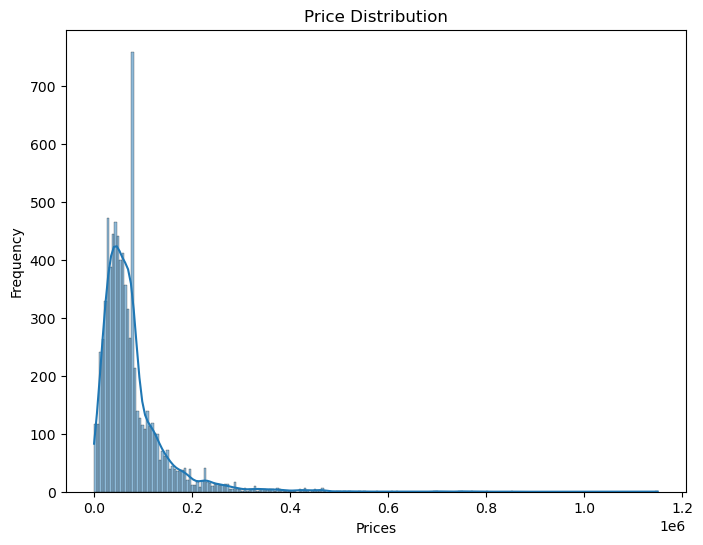

In [32]:
plt.figure(figsize=[8,6])
sns.histplot(data=df , x='Price' , kde=True )
plt.title('Price Distribution')
plt.xlabel('Prices')
plt.ylabel('Frequency')
plt.show()

It seems that the Price distribution is right-skewed, with most cars priced below 100,000 and a few expensive cars above 150,000.

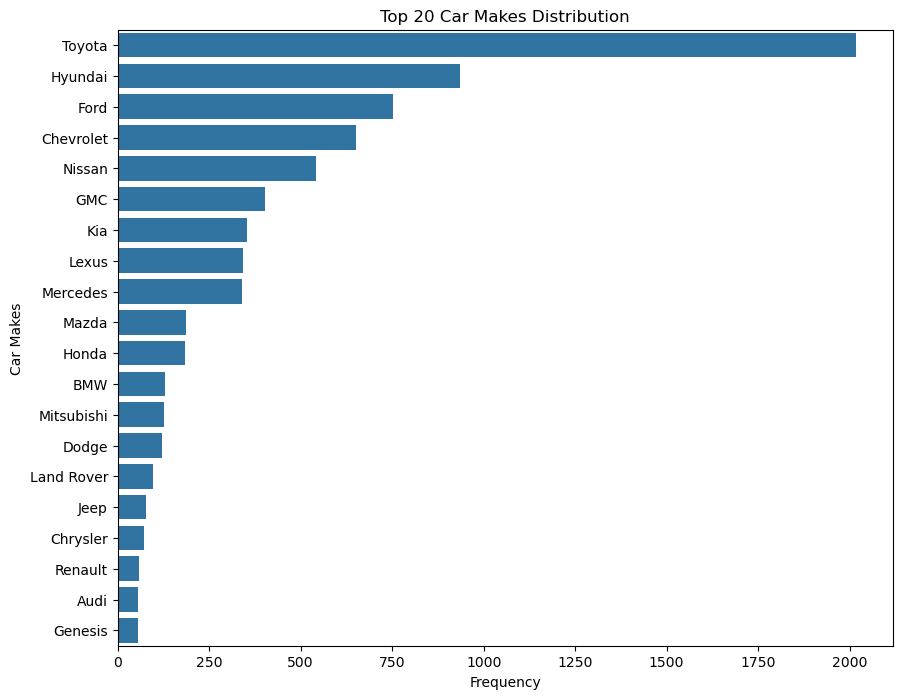

In [33]:
top_brands = df['Make'].value_counts().nlargest(20).index

plt.figure(figsize=(10, 8))  
sns.countplot(data=df[df['Make'].isin(top_brands)], y='Make', order=top_brands)
plt.title('Top 20 Car Makes Distribution')
plt.xlabel('Frequency')
plt.ylabel('Car Makes')
plt.show()

it seems that the most common car make in the dataset is Toyota, followed by Ford and Nissan

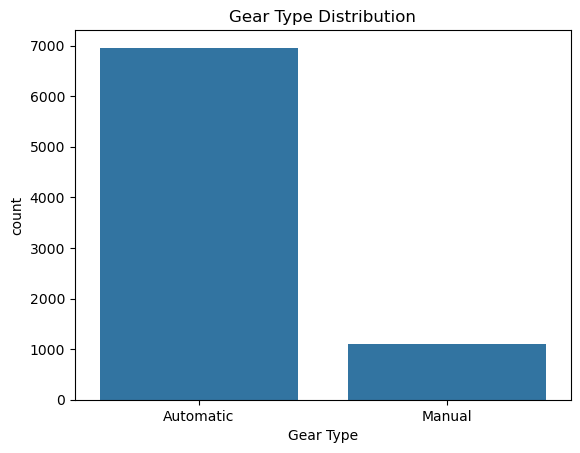

In [34]:
sns.countplot(data=df, x='Gear_Type')
plt.title('Gear Type Distribution')
plt.xlabel('Gear Type') 
plt.show()

it seems that most cars are Automatic

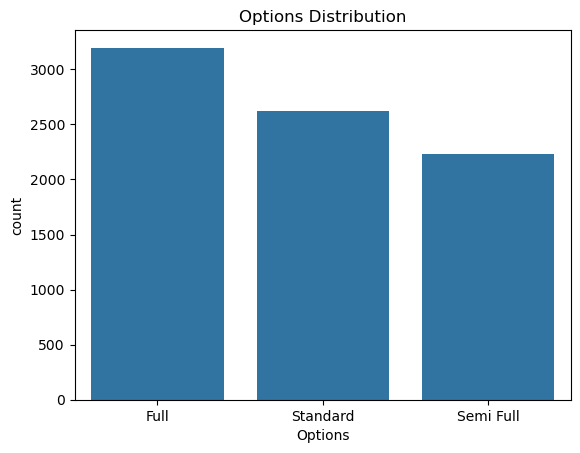

In [35]:
sns.countplot(data=df, x='Options')
plt.title('Options Distribution')
plt.xlabel('Options')
plt.show()

it seems that most of cars are with full options then standard then semi full

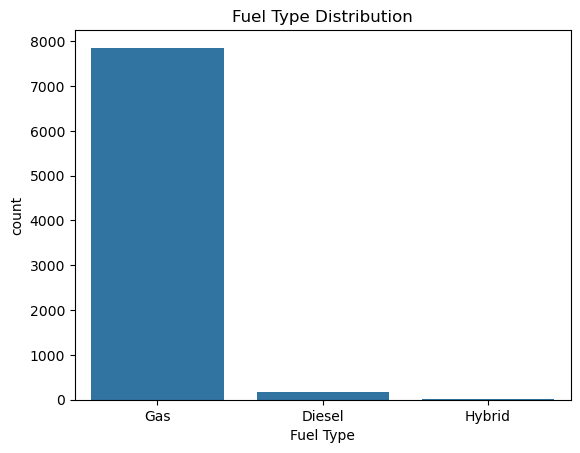

In [36]:
sns.countplot(data=df, x='Fuel_Type')
plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')
plt.show()

it seems that most cars are Gas

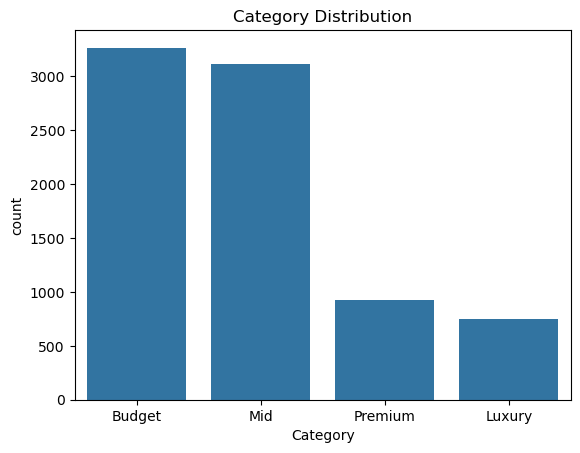

In [37]:
sns.countplot(data=df, x='Category')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.show()

it seems that most cars are in Budget and Mid

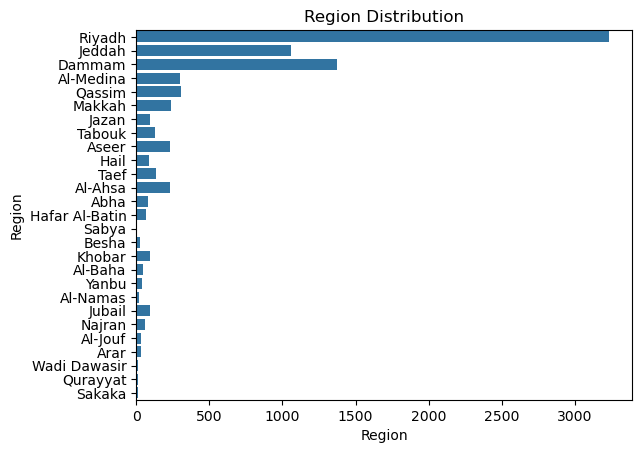

In [38]:
sns.countplot(data=df, y='Region')
plt.title('Region Distribution')
plt.xlabel('Region')
plt.show()

it seems the most capacity city is Riyadh

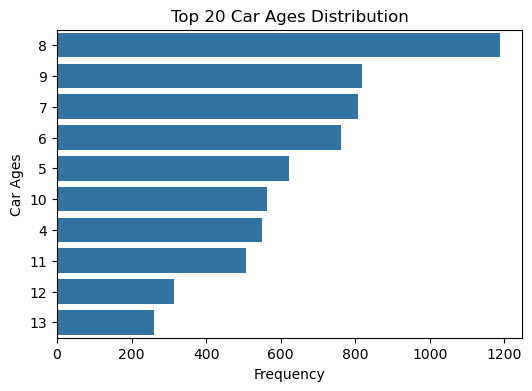

In [39]:
top_Ages = df['Car_Age'].value_counts().nlargest(10).index

plt.figure(figsize=(6, 4))  
sns.countplot(data=df[df['Car_Age'].isin(top_Ages)], y='Car_Age', order=top_Ages)
plt.title('Top 20 Car Ages Distribution')
plt.xlabel('Frequency')
plt.ylabel('Car Ages')
plt.show()

it seems that most of the cars are between 4 and 13 years old, with a peak around 8 years old

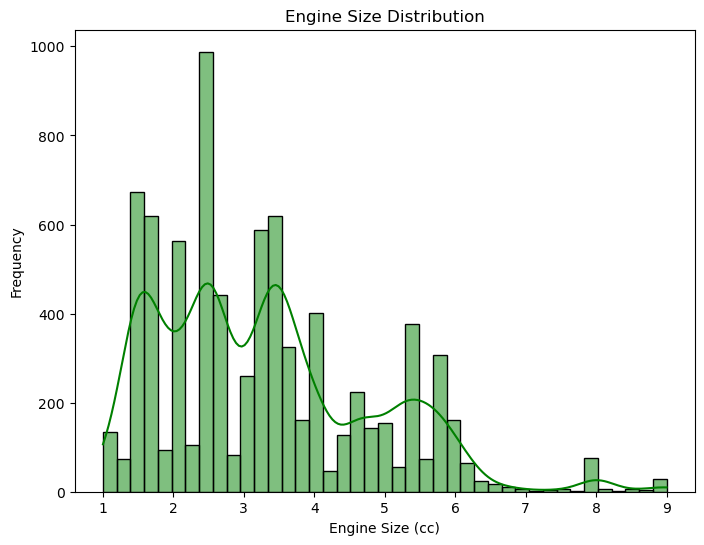

In [48]:
plt.figure(figsize=[8,6])
sns.histplot(data=df , x='Engine_Size', kde=True , color='g')
plt.title('Engine Size Distribution')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Frequency')
plt.show()


it seems like that most cars have 2500 CC